# 01 — Data Exploration
**Prior Authorization Automation | Hannah-Hiltz GitHub Portfolio**

This Python file explores the 25-case synthetic PA dataset — label distribution, clinical category breakdown, insurance plan mix, documentation quality, and what the raw notes look like before NLP extraction.

This is primarily to ensure that the data is clean, well-balanced, and causes no downstream errors.


In [1]:
# Environment Setup (works in Google Colab AND local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data'
else:
  BASE = '..'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working Directory: {os.getcwd()}')

Mounted at /content/drive
Environment: Google Colab
Working Directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data


In [2]:
#Common Imports
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

#Load dataset
with open('../data/pa_synthetic_dataset.json', 'r') as f:
    cases = json.load(f)

df = pd.DataFrame(cases)
print(f'Loaded {len(df)} cases')
print(f'Columns: {list(df.columns)}')

Loaded 25 cases
Columns: ['case_id', 'insurance_type', 'insurance_plan_type', 'clinical_category', 'drug_requested', 'icd10_codes', 'cpt_codes', 'note', 'documentation_quality', 'true_label', 'extraction', 'gold_standard_letter']


## Dataset Overview

In [3]:
#General Dataset Overview
print(f'Total cases: {len(df)}')
print(f'Clinical categories: {df.clinical_category.nunique()}')
print(f'Insurance plan types: {df.insurance_plan_type.nunique()}')
print(f'Unique insurers: {df.insurance_type.nunique()}')
print()
print('Label Distribution:')
print(df.true_label.value_counts().to_string())
print()
print('Documentation quality:')
print(df.documentation_quality.value_counts().to_string())

Total cases: 25
Clinical categories: 13
Insurance plan types: 6
Unique insurers: 20

Label Distribution:
true_label
APPROVE           15
DENY               7
PENDING_REVIEW     3

Documentation quality:
documentation_quality
strong     16
weak        7
partial     2


In [4]:
#Preview a raw clinical note

sample = df.iloc[0]
print(f'Case:{sample.case_id}')
print(f'Insurer:{sample.insurance_type}')
print(f'Category:{sample.clinical_category}')
print(f'Label:{sample.true_label}')
print(f'Doc quality:{sample.documentation_quality}')
print()

print('--- CLINICAL NOTE ---')
print(sample.note.strip())
print()

print('--- GOLD STANDARD LETTER ---')
print(sample.gold_standard_letter.strip())

Case:PA-001
Insurer:Aetna HMO
Category:biologic_dermatology
Label:APPROVE
Doc quality:strong

--- CLINICAL NOTE ---
Patient is a 31-year-old female with moderate-to-severe atopic dermatitis (ICD-10: L20.9) affecting 35% BSA with EASI score of 28.4. Completed 8-week trial of triamcinolone 0.1% cream (inadequate response, BSA unchanged at 33%). Completed 12-week trial of tacrolimus 0.1% ointment (discontinued due to burning intolerance, documented visit 03/2024). Dermatology consulted and recommends dupilumab given failed topical therapies and significant impact on quality of life (DLQI 18). No active ocular herpes or conjunctivitis. No live vaccines pending.

--- GOLD STANDARD LETTER ---
Patient is a 31-year-old female with a confirmed diagnosis of moderate-to-severe atopic dermatitis (ICD-10: L20.9) with objective disease burden documented at 35% BSA involvement and an EASI score of 28.4, consistent with severe disease classification. The patient has completed adequate trials of two to

## Label and Category Distribution

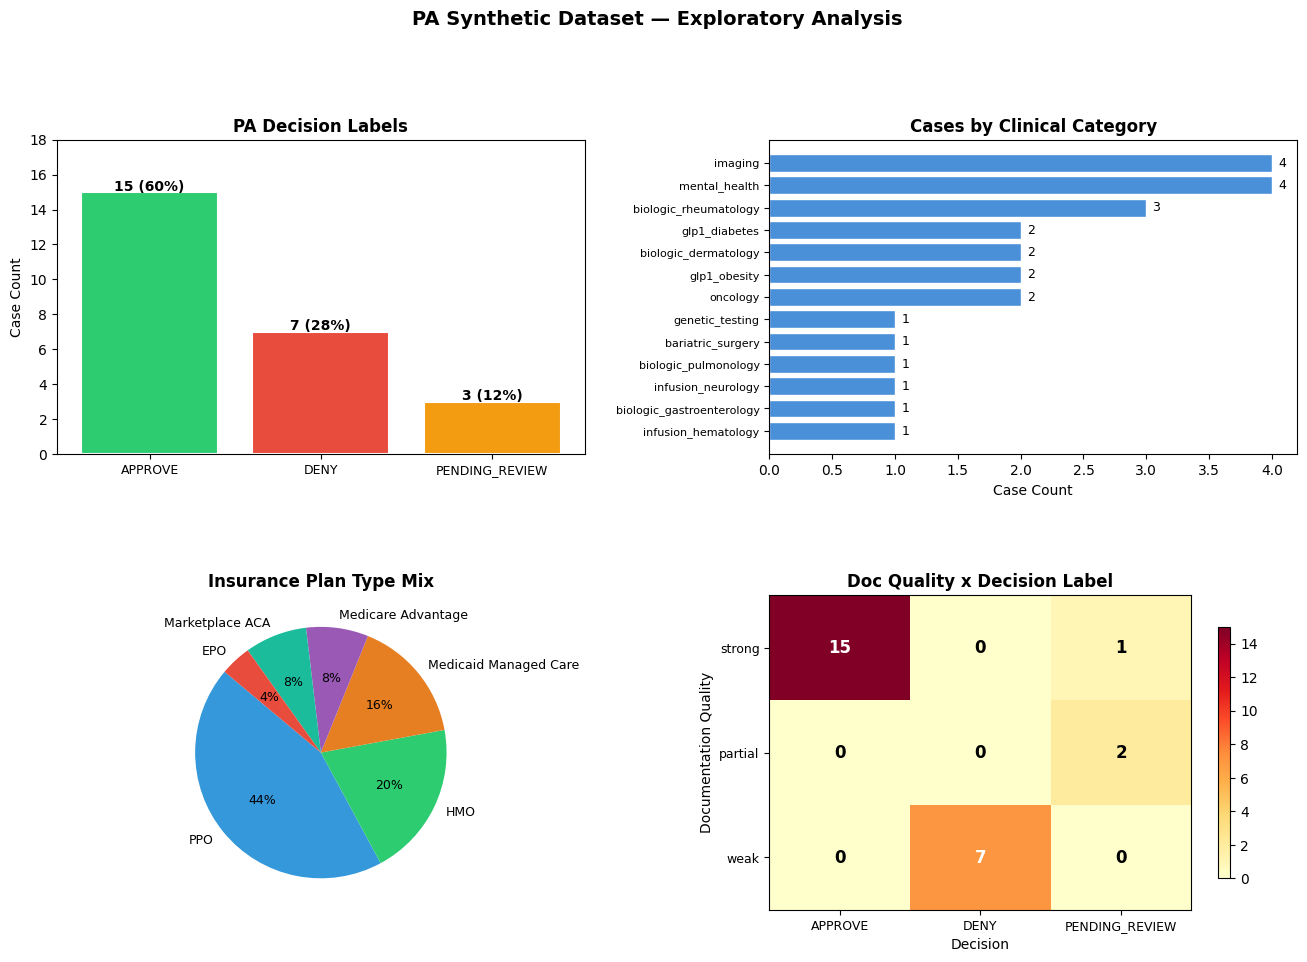

Saved to evaluation/01_dataset_overview.png


In [5]:
colors = {'APPROVE': '#2ecc71', 'DENY': '#e74c3c', 'PENDING_REVIEW': '#f39c12'}
cat_color = '#4a90d9'
fig = plt.figure(figsize=(16,10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

#Label Distribution
ax1 = fig.add_subplot(gs[0,0])
label_counts = df.true_label.value_counts()
bars = ax1.bar(label_counts.index, label_counts.values,
               color=[colors[l] for l in label_counts.index],
               edgecolor = 'white', linewidth = 1.5)
for bar, val in zip(bars, label_counts.values):
  ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
           f'{val} ({val/len(df):.0%})', ha='center', fontsize=10, fontweight= 'bold')
ax1.set_title("PA Decision Labels", fontweight='bold')
ax1.set_ylabel('Case Count')
ax1.set_ylim(0, max(label_counts.values) + 3)
ax1.tick_params(axis='x', labelsize=9)

#Clinical Categories
ax2 = fig.add_subplot(gs[0, 1])
cat_counts = df.clinical_category.value_counts()
ax2.barh(cat_counts.index, cat_counts.values, color=cat_color,
         edgecolor='white', linewidth=1)
for i, val in enumerate(cat_counts.values):
    ax2.text(val + 0.05, i, str(val), va='center', fontsize=9)
ax2.set_title('Cases by Clinical Category', fontweight='bold')
ax2.set_xlabel('Case Count')
ax2.tick_params(axis='y', labelsize=8)
ax2.invert_yaxis()

#Insurance Plan Types
ax3 = fig.add_subplot(gs[1, 0])
plan_counts = df.insurance_plan_type.value_counts()
ax3.pie(plan_counts.values, labels=plan_counts.index, autopct='%1.0f%%',
        startangle=140,
        colors=['#3498db','#2ecc71','#e67e22','#9b59b6','#1abc9c','#e74c3c'],
        textprops={'fontsize': 9})
ax3.set_title('Insurance Plan Type Mix', fontweight='bold')

#Doc Quality and Label Heatmap
ax4 = fig.add_subplot(gs[1, 1])
cross = pd.crosstab(df.documentation_quality, df.true_label)
cross = cross.reindex(index=['strong','partial','weak'],
                      columns=['APPROVE','DENY','PENDING_REVIEW'], fill_value=0)
im = ax4.imshow(cross.values, cmap='YlOrRd', aspect='auto')
ax4.set_xticks(range(len(cross.columns)))
ax4.set_yticks(range(len(cross.index)))
ax4.set_xticklabels(cross.columns, fontsize=9)
ax4.set_yticklabels(cross.index, fontsize=9)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        ax4.text(j, i, cross.values[i, j], ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if cross.values[i, j] > 4 else 'black')
ax4.set_title('Doc Quality x Decision Label', fontweight='bold')
ax4.set_xlabel('Decision')
ax4.set_ylabel('Documentation Quality')
plt.colorbar(im, ax=ax4, shrink=0.8)

fig.suptitle('PA Synthetic Dataset — Exploratory Analysis',
             fontsize=14, fontweight='bold', y=1.01)
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to evaluation/01_dataset_overview.png')

## Note Length Analysis

NOTE LENGTH STATS
       note_word_count  note_char_count  letter_word_count
count             25.0             25.0               25.0
mean              58.4            427.6               99.0
std               10.8             79.5               11.7
min               37.0            281.0               73.0
25%               50.0            386.0               95.0
50%               59.0            414.0              100.0
75%               68.0            493.0              106.0
max               75.0            564.0              123.0



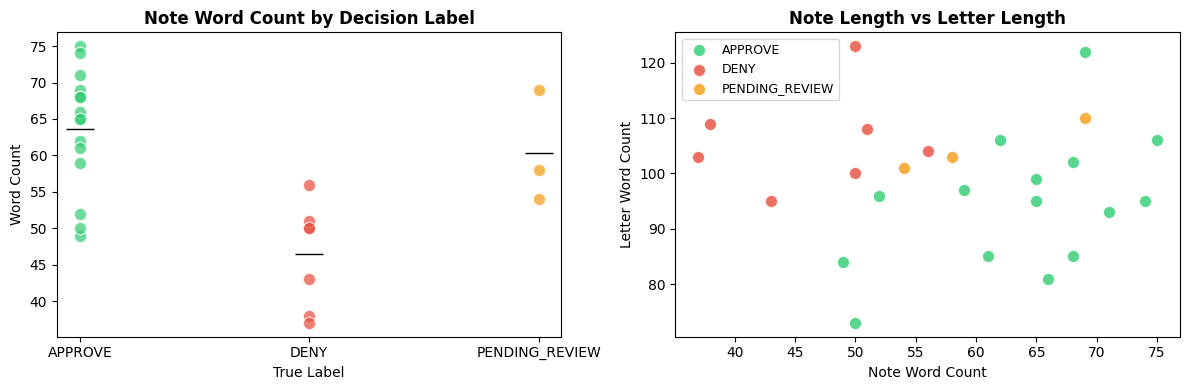

In [6]:
df['note_word_count']   = df.note.str.split().str.len()
df['note_char_count']   = df.note.str.len()
df['letter_word_count'] = df.gold_standard_letter.str.split().str.len()

print('NOTE LENGTH STATS')
print(df[['note_word_count','note_char_count','letter_word_count']].describe().round(1).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in colors.items():
    subset = df[df.true_label == label]['note_word_count']
    axes[0].scatter([label]*len(subset), subset,
                    color=color, alpha=0.7, s=80, edgecolors='white')
    axes[0].plot([label], [subset.mean()], marker='_',
                 color='black', markersize=20, linewidth=3)
axes[0].set_title('Note Word Count by Decision Label', fontweight='bold')
axes[0].set_ylabel('Word Count')
axes[0].set_xlabel('True Label')

for label, color in colors.items():
    subset = df[df.true_label == label]
    axes[1].scatter(subset.note_word_count, subset.letter_word_count,
                    color=color, label=label, alpha=0.8, s=80, edgecolors='white')
axes[1].set_title('Note Length vs Letter Length', fontweight='bold')
axes[1].set_xlabel('Note Word Count')
axes[1].set_ylabel('Letter Word Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('evaluation/01_note_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## Extraction Ground Truth Preview

In [7]:
ext_rows = []
for case in cases:
    ext = case.get('extraction', {})
    ext_rows.append({
        'case_id':               case['case_id'],
        'true_label':            case['true_label'],
        'documentation_quality': case['documentation_quality'],
        'n_icd_codes':           len(ext.get('diagnoses', [])),
        'n_cpt_codes':           len(ext.get('procedures', [])),
        'n_drugs_failed':        len(ext.get('drugs_failed', [])),
        'n_labs':                len(ext.get('lab_values', {})),
        'n_doc_gaps':            len(ext.get('documentation_gaps', [])),
        'prior_therapy_failure': ext.get('has_prior_therapy_failure', False),
        'specialist_support':    ext.get('has_specialist_support', False),
    })

df_ext = pd.DataFrame(ext_rows)

print('EXTRACTION GROUND TRUTH SUMMARY')
print(df_ext.groupby('true_label')[[
    'n_icd_codes','n_drugs_failed','n_labs','n_doc_gaps',
    'prior_therapy_failure','specialist_support'
]].mean().round(2).to_string())
print()
print('Prior therapy failure by label:')
print(df_ext.groupby(['true_label','prior_therapy_failure']).size().to_string())
print()
print('Specialist support by label:')
print(df_ext.groupby(['true_label','specialist_support']).size().to_string())

EXTRACTION GROUND TRUTH SUMMARY
                n_icd_codes  n_drugs_failed  n_labs  n_doc_gaps  prior_therapy_failure  specialist_support
true_label                                                                                                
APPROVE                1.60            1.40    2.53        0.00                   0.67                0.93
DENY                   1.14            0.00    0.71        3.86                   0.00                0.00
PENDING_REVIEW         1.67            1.33    3.00        1.33                   0.33                1.00

Prior therapy failure by label:
true_label      prior_therapy_failure
APPROVE         False                     5
                True                     10
DENY            False                     7
PENDING_REVIEW  False                     2
                True                      1

Specialist support by label:
true_label      specialist_support
APPROVE         False                  1
                True                

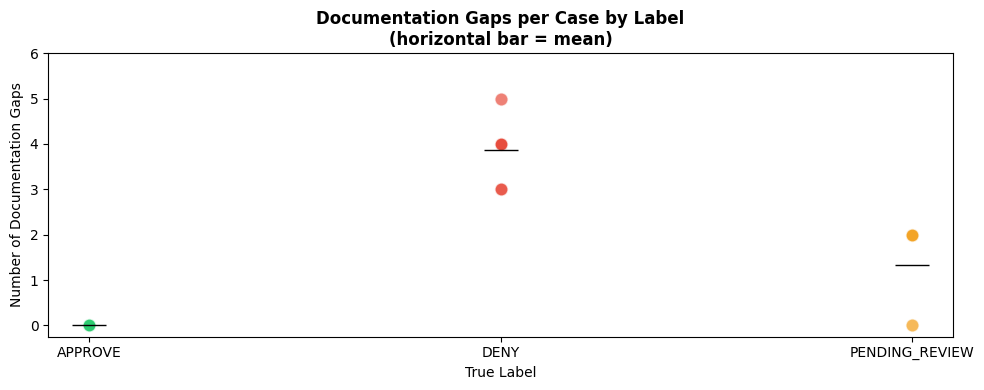

Key insight: DENY cases average 3.9 doc gaps vs 0.0 for APPROVE


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in colors.items():
    subset = df_ext[df_ext.true_label == label]
    ax.scatter([label]*len(subset), subset.n_doc_gaps,
               color=color, alpha=0.7, s=90, edgecolors='white', label=label)
    ax.plot([label], [subset.n_doc_gaps.mean()],
            marker='_', color='black', markersize=24, linewidth=3)
ax.set_title('Documentation Gaps per Case by Label\n(horizontal bar = mean)', fontweight='bold')
ax.set_ylabel('Number of Documentation Gaps')
ax.set_xlabel('True Label')
ax.set_yticks(range(0, int(df_ext.n_doc_gaps.max()) + 2))
plt.tight_layout()
plt.savefig('evaluation/01_doc_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: DENY cases average',
      round(df_ext[df_ext.true_label=='DENY'].n_doc_gaps.mean(), 1),
      'doc gaps vs',
      round(df_ext[df_ext.true_label=='APPROVE'].n_doc_gaps.mean(), 1),
      'for APPROVE')

## Key Takeaways

- **Label skew:** 60% APPROVE / 28% DENY / 12% PENDING reflects realistic PA volumes

- **Documentation quality is a strong DENY signal** — all weak-documentation cases are DENY or PENDING

- **Prior therapy failure** is the single most predictive approval signal.

- **Note length does not predict label** — Short notes appear in both APPROVE and DENY, insinuating it is content and quality, not length, that leads to denials.

- **Documentation gaps** sharply differentiate DENY from APPROVE cases.

**Next:** `02_nlp_extraction.ipynb`